# Mock exam

In [85]:
import numpy as np
from sympy import *
import matplotlib.pyplot as plt

## MC part

A: Relative error: 4

In [ ]:
def absolute_error(approx,exact):
    return np.abs(approx - exact)

def relative_error(approx,exact):
    return absolute_error(approx,exact) / (exact)

exact = 4.996
approx = 5.00
rel = relative_error(approx,exact)

print(rel)

0.0008006405124098397


B: Interpolation: Lagrange form: 3

In [15]:
def s_lambdapoly(xi,xj,x):
    return (x - xj) / (xi - xj)

def s_initiate_notes(n, symbol = 'x', start_index = 0):
    s = start_index
    x = {i : symbols(f"{symbol}{i}") for i in range(s,n + s)} 

    return x


# x = s_initiate_notes(4,1)
# display(s_lambdapoly(x[1],x[2],1))

def s_cardinalpoly(i: int, variables: dict|tuple, x = symbols("x")):
    """
    For variables == tuple: variables = (n, symbol, start_inx).

    This is used for when the function acts as a standalone
    """
    if type(variables) == tuple:
        variables = s_initiate_notes(n = variables[0], symbol=variables[1], start_index=variables[2])
    l_i = 1
    for j in variables:
        if j != i and type(j):
            l_i *= s_lambdapoly(variables[i],variables[j],x)

    return l_i


def s_lagrangepoly(n: int, start_index: int, x = symbols('x')):
    s = start_index
    data = {'x': s_initiate_notes(n, 'x', s), 'y': s_initiate_notes(n, 'y', s)}
    
    p = sum([s_cardinalpoly(i, data['x']) * data['y'][i] for i in range(s, n + s)])

    return p


s_cardinalpoly(2, (4,symbols("x"),1))

(x - x1)*(x - x3)*(x - x4)/((-x1 + x2)*(x2 - x3)*(x2 - x4))

C - secant method: 4

In [20]:
def Secant(f, x0, x1, nmax):
    """
    This function implements the secant method to find a root of the function f.
    
    f: the function whose root we want to find
    x0: the initial guess for the root
    x1: the second initial guess for the root
    nmax: the maximum number of iterations
    
    returns: a root of the function f, or None if no root is found
    """
    # Set a tolerance for the error
    tol = 1e-6
    X = [x1]
    # Iterate nmax times
    for n in range(nmax):
        # Compute the value of the function at x0 and x1
        f0 = f(x0)
        f1 = f(x1)
        
        # Compute the secant of the function at x0 and x1
        sec = (x1 - x0) / (f1 - f0)
        
        # Compute the next guess for the root
        x2 = x1 - sec * f1
        X.append(x2)
        # Check if the error is within the tolerance
        if abs(x2 - x1) < tol:
            return X
        
        # Update x0 and x1 for the next iteration
        x0 = x1
        x1 = x2
    
    # If no root was found, return None
    return X

f = lambda x: x**2 - x - 12
x0 = 0; x1 = 1
Secant(f,x0,x1,1000)

ZeroDivisionError: division by zero

D: Solving a linear system: 3

In [22]:
def time_analysis(n: int, n_init: int, t_init: float, system_complexities: list):
    ops_init = 0
    ops = 0
    for s in system_complexities:
        ops_init += s(n_init)
        ops += s(n)
    time_per_op = t_init / ops_init
    time = ops * time_per_op

    return time

print(time_analysis(800, 200, 0.36, [lambda n: 1/3 * n**3]))

23.04


E: Sensitivity analysis: 1

In [23]:
def sensitivity_bound(A, b, btilde, relative=True, order = 2):
    db = btilde - b

    if relative:
        kappa = np.linalg.cond(A, order)
        return kappa * np.linalg.norm(db, order) / np.linalg.norm(b, order)
    else:
        Ainv_norm = np.linalg.norm(np.linalg.inv(A), order)
        return Ainv_norm * np.linalg.norm(db, order)

#Example
A = np.array([
    [3.1,-1.2,2.6],
    [1.5,-0.7,3.6],
    [-4.1,1.1,0.7]
])
b = np.array([0.654,0.765,-1.042])
btilde = np.array([0.657, 0.761, -1.039])
sensitivity_bound(A,b,btilde)


np.float64(0.2828325384957113)

F: Initial-value problems: 4

See day8-chapter 7 (slides) 

## Question 1


### 1.1)
We first define given integrand and the composite Simpson's rule as

In [42]:
f = lambda x: np.exp(1 - x**2)
a, b = (0,1)

def MySimpson(f, a, b, n):

    if n % 2:
        print("n must be even")
        return float("nan")
    h = (b - a) / n
    f_evaluations = [f(a + i * h) for i in range(n + 1)]
    
    for i in range(1, n, 2):
        f_evaluations[i] *= 4
    for i in range(2, n-1, 2):
        f_evaluations[i] *= 2
    
    return h / 3 * sum(f_evaluations)

Using the function we get the approximation

In [54]:
n = 500
S_true = MySimpson(f,a,b, n)
print(f"True S = {S_true}")


True S = 2.0300784692790597


i.e. we get the "true" approximation $\bar{S} = 2.0300784692790597$.

The algorithm is now run for the given n, and the absolute errors, $|\bar{S} - S_n|$, are calculated for each.

In [193]:
def absolute_error(approx,exact):
    return np.abs(approx - exact)

ns = [20,40,60,80,100]

S = {n : MySimpson(f,a,b,n) for n in ns}
e = {n : absolute_error(S[n], S_true) for n in ns}

for n in ns:
    s = f"{e[n]:.3E}"
    print(f"e_{n} = {s}")

e_20 = 1.388E-07
e_40 = 8.679E-09
e_60 = 1.714E-09
e_80 = 5.422E-10
e_100 = 2.219E-10


The print statement shows the errors in scientific notation, with $3$ significant digits

### 1.2.1)


In [186]:
def display_normal_eq(x,y, basis):
    x = np.array(x); y = np.array(y)
    A = np.array(basis(x)).T

    print("system matrix: A.T A =")
    print(A.T@A)
    print("RHS: A.T b = ")
    print(A.T@y)

x = np.array(ns)
y = np.array([np.log(e[n]) for n in ns])
basis = lambda n: [np.ones_like(n), -np.log(n)]
display_normal_eq(x,y,basis)


system matrix: A.T A =
[[  5.         -19.76615311]
 [-19.76615311  79.75565074]]
RHS: A.T b = 
[-98.10130449 394.27979491]


1.2.2)

c: [-3.80548359  4.00046919]


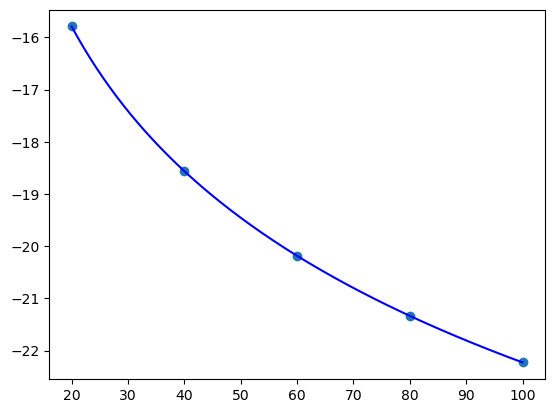

In [ ]:
def normal_eq(x, y, basis):
    A = np.array(basis(x)).T
    c = np.linalg.solve(A.T @ A, A.T @ y)

    xx = np.linspace(x.min(), x.max(), 200)
    Axx = np.array(basis(xx)).T
    yy = Axx @ c
    return (xx, yy), c



fit, c = normal_eq(x,y, basis)
print("c:",c)
plt.plot(x,y,'o', fit[0], fit[1], '-b')

i.e. $b = -3.80, \alpha = 4.00$

## Question 2

In [195]:
def F(X):
    FX = np.array([
        -X[0]**2 - X[0] + 2*X[1] - 18,
        (X[0] - 1)**2 + (X[1] - 6)**2 - 25
        ])
    
    dFX = np.array([
        [-2*X[0] - 1, 2],
        [2*X[0]- 2, 2*X[1] - 12]
        ])
    
    return FX, dFX

## Question 4